# 01 — Carga y limpieza — Black Basta

Parsea `blackbasta_chats.json`, limpia el dataset y genera  
`data/processed/blackbasta_unified.parquet`.

## 0. Setup

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path('src').resolve()))

import pandas as pd
import matplotlib.pyplot as plt
from loaders import load_blackbasta

RAW_FILE      = Path('/home/drjekyll/Documentos/umbrella/data_bruto/Ransomware/BlackBasta-Chats-main/blackbasta_chats.json')
PROCESSED_DIR = Path('../data/processed')
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

assert RAW_FILE.exists(), f'No se encuentra {RAW_FILE}'
print('Setup OK')

Setup OK


## 1. Carga

In [2]:
print('Cargando blackbasta_chats.json...')
df = load_blackbasta(RAW_FILE)
print(f'  → {len(df):,} mensajes | rango: {df.timestamp.min()} → {df.timestamp.max()}')
display(df.head(3))

Cargando blackbasta_chats.json...
  → 195,407 mensajes | rango: 2023-09-18 13:35:07+00:00 → 2024-09-28 17:11:23+00:00


,timestamp,username,channel,message,source
0,2023-09-18 13:35:07+00:00,usernamenn,VdvDXHFZwWDpIAtpCj,BAZA,blackbasta
1,2023-09-18 13:50:31+00:00,usernamess,uJZKZVgGmmSiNvobZH,!!!,blackbasta
2,2023-09-18 17:43:18+00:00,usernameyy,FtoGkSqUPiGjGNKkOl,"cpu 2core 2.4 ghz, 4 gb ram, 100 gb space x2",blackbasta


## 2. Limpieza

In [3]:
n_before = len(df)

# Eliminar mensajes vacíos o solo whitespace
df = df[df['message'].str.strip().str.len() > 0]

# Eliminar duplicados exactos
df = df.drop_duplicates(subset=['timestamp', 'username', 'message'])

# Eliminar timestamps inválidos
df = df.dropna(subset=['timestamp'])

# Normalizar username: lowercase, strip
df['username'] = df['username'].str.strip().str.lower()
df['channel']  = df['channel'].str.strip()

df = df.sort_values('timestamp').reset_index(drop=True)

print(f'Filas eliminadas : {n_before - len(df):,}')
print(f'Mensajes limpios : {len(df):,}')

Filas eliminadas : 10
Mensajes limpios : 195,397


## 3. Detección de idioma

In [4]:
from langdetect import detect, LangDetectException
from tqdm.auto import tqdm

def safe_detect(text):
    try:
        return detect(str(text)[:200])
    except LangDetectException:
        return 'und'

tqdm.pandas(desc='Detectando idioma')
df['lang'] = df['message'].progress_apply(safe_detect)

print('\nDistribución de idiomas:')
print(df.lang.value_counts().head(10).to_string())

/home/drjekyll/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Detectando idioma: 100%|████████████████████████████████████████████████████████████| 195397/195397 [04:35<00:00, 709.77it/s]


Distribución de idiomas:
lang
ru     106749
mk      17055
bg      16666
und     13492
en      12394
uk       6897
tl       2349
ca       2187
et       1965
cy       1704


## 4. Estadísticas finales

In [5]:
print('=== DATASET BLACK BASTA ===')
print(f'  Mensajes totales : {len(df):,}')
print(f'  Actores únicos   : {df.username.nunique()}')
print(f'  Canales únicos   : {df.channel.nunique()}')
print(f'  Rango temporal   : {df.timestamp.min().date()} → {df.timestamp.max().date()}')
print()
print('Top 20 actores:')
print(df.groupby('username').size().sort_values(ascending=False).head(20).to_string())

=== DATASET BLACK BASTA ===
  Mensajes totales : 195,397
  Actores únicos   : 49
  Canales únicos   : 79
  Rango temporal   : 2023-09-18 → 2024-09-28

Top 20 actores:
username
usernamegg        83066
lapa              26258
w                 13439
usernamenn         8509
usernameyy         7172
n3auxaxl           6386
usernameugway      6075
usernamess         5504
nickolas           3669
cameron777         3641
muaddib6           2454
ssd                2280
burito             2169
usernameww         1694
cob_crypt_ward     1678
usernamevv         1641
lincoln            1640
usernamemm         1609
usernamezz         1534
usernamett         1516


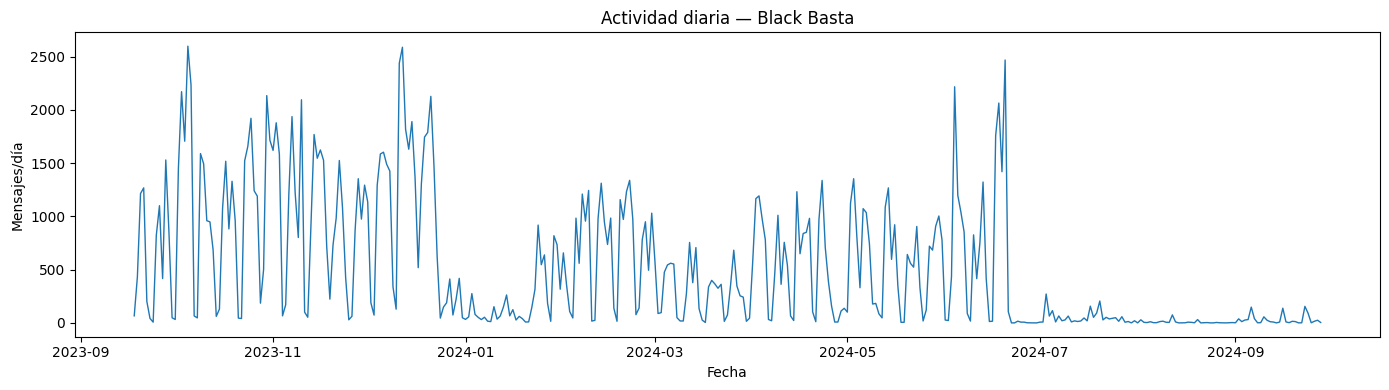

In [6]:
daily = df.set_index('timestamp').resample('D').size()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily.index, daily.values, linewidth=1)
ax.set_title('Actividad diaria — Black Basta')
ax.set_xlabel('Fecha')
ax.set_ylabel('Mensajes/día')
plt.tight_layout()
plt.show()

## 5. Guardar

In [7]:
out_path = PROCESSED_DIR / 'blackbasta_unified.parquet'
df.to_parquet(out_path, index=False)
print(f'Guardado: {out_path}')
print(f'Tamaño:   {out_path.stat().st_size / 1024**2:.1f} MB')
print(f'Columnas: {list(df.columns)}')
print(f'Tipos:\n{df.dtypes.to_string()}')

Guardado: ../data/processed/blackbasta_unified.parquet
Tamaño:   9.2 MB
Columnas: ['timestamp', 'username', 'channel', 'message', 'source', 'lang']
Tipos:
timestamp    datetime64[us, UTC]
username                     str
channel                      str
message                      str
source                       str
lang                         str
